# <span style="color:red"> QTM 151 - Practice Quiz </span>

<font size="5"> 

Print your name below

<font size = "5">

Import pandas

In [1]:
import pandas as pd
import numpy as np


(1) Replace the values of a column

Consider the DataFrame df_books created below.
In the "language" column, change the values "Eng" and "Jap" to "English" and "Japanese" respectively.

Do this by using the .replace() method.

Fitted coefficients:
a = 1.9494, b = -2.9181, c = 4.6971


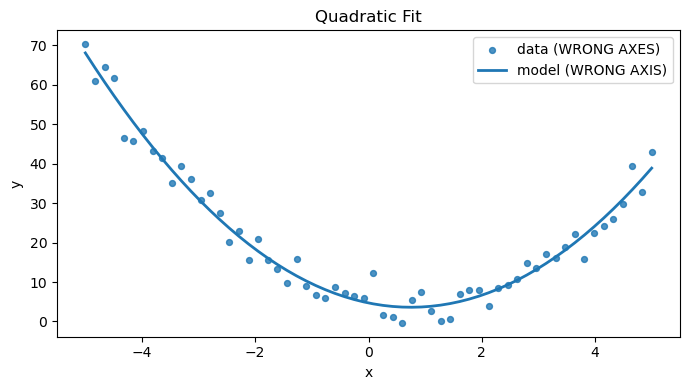

In [6]:
# Cell 1: fit quadratic model (correct code — do NOT modify)
import numpy as np
import pandas as pd

# reproducible data
rng = np.random.default_rng(42)
x = np.linspace(-5, 5, 60)
y_true = 2.0 * x**2 - 3.0 * x + 4.0
y = y_true + rng.normal(0, 4, size=x.size)

df = pd.DataFrame({"x": x, "y": y})

# fit y ≈ a*x^2 + b*x + c
a, b, c = np.polyfit(df["x"], df["y"], deg=2)

def predict(x_vals):
    return a * x_vals**2 + b * x_vals + c

print("Fitted coefficients:")
print(f"a = {a:.4f}, b = {b:.4f}, c = {c:.4f}")







# Cell 2: plotting (THIS PLOT IS WRONG — fix this cell only)
import matplotlib.pyplot as plt

# BUGS intentionally present:
# 1) scatter axes swapped
# 2) model line plotted against wrong axis & unsorted domain
# 3) misleading labels

y_pred = predict(df["x"])

plt.figure(figsize=(7, 4))
# wrong: swapped x/y for scatter
plt.scatter(df["x"], df["y"], s=18, alpha=0.8, label="data (WRONG AXES)")

# wrong: plotting y_pred against y (should be x)
plt.plot(df["x"], y_pred, lw=2.0, label="model (WRONG AXIS)")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Quadratic Fit")
plt.legend()
plt.tight_layout()
plt.show()

# TODO: 你的任务：
#  - 仅在本单元格中修改，使之成为正确图：
#    * x 轴为 df['x']，y 轴为 df['y']
#    * 散点为 (x, y)
#    * 模型线为在排序后的 x_grid 上的 predict(x_grid)，保证曲线平滑
#    * 正确的轴标签/标题/图例


<font size = "5">

(2) Recode a numeric column

<font size = "3">

- Consider the DataFrame ``df_books`` created above
- Recode the "year" column into a new column "year_brackets" <br>
with the following categories:

$\qquad$ ``` ["Before 1950", "1950–1999", "2000 onwards"] ```

$\qquad$ HINT: Use the "pd.cut()" command.

In [26]:
# your code here


df_books["year_category"] = pd.cut(df_books["year"],
                            bins = [float("-inf"), 1950, 1999, float("inf")],
                            right = True,
                            labels = ["Before 1950", "1950–1999", "2000 onwards"])
df_books

#circuits["hemisphere"] = pd.cut(circuits["lat"], 
                    #            bins = lat_bins,
                      #          right = True,
                     #           labels = lat_labels)

,title,language,year,languages,year_category
0,Kafka on the Shore,Jap,2002,Japanese,2000 onwards
1,Norwegian Wood,Jap,1987,Japanese,1950–1999
2,1984,Eng,1949,English,Before 1950
3,Animal Farm,Eng,1945,English,Before 1950
4,The Wind-Up Bird Chronicle,Jap,1994,Japanese,1950–1999


<font size = "5">

(3) Rename column

<font size = "3">

- Consider the DataFrame ``df_movies`` created above
- Rename the column "runtime" to "runtime(minutes)"

In [27]:
# Write your answer here:
#circuits = circuits.rename(columns={'Uniform Resource Locator': 'url'})

df_books = df_books.rename(columns={"year" : "publication_year"})
df_books

,title,language,publication_year,languages,year_category
0,Kafka on the Shore,Jap,2002,Japanese,2000 onwards
1,Norwegian Wood,Jap,1987,Japanese,1950–1999
2,1984,Eng,1949,English,Before 1950
3,Animal Farm,Eng,1945,English,Before 1950
4,The Wind-Up Bird Chronicle,Jap,1994,Japanese,1950–1999


<font size = "5">

(4) Merge dataset

<font size = "3">

- Consider the DataFrames ``df_movies`` (created above) and ``df_scores`` (created below)
- Create a new dataset using  ```pd.merge()``` using <br>
"df_movies" as the primary dataset, and <br>
"df_scores" as the secondary dataset, merging on <br>
the column "title"
- You should **ONLY** merge the "imdb_score" column <br>
from the secondary dataset (not the "director" column)

HINT: Use ```[[...]]``` to extract a subset of columns <br>
from the secondary dataset before merging

In [28]:
# Create example DataFrame
ratings = [8.7, 8.5, 9.1, 8.9, 8.6]
authors = ["Haruki Murakami", "Haruki Murakami", "George Orwell", "George Orwell", "Haruki Murakami"]

df_ratings = pd.DataFrame({
    "title": titles,
    "rating": ratings,
    "author": authors
})

# Write your answer here:
df_merged = pd.merge(df_books,
                     df_ratings[["title", "rating"]],
                     on = "title",
                     how = "left")
df_merged

,title,language,publication_year,languages,year_category,rating
0,Kafka on the Shore,Jap,2002,Japanese,2000 onwards,8.7
1,Norwegian Wood,Jap,1987,Japanese,1950–1999,8.5
2,1984,Eng,1949,English,Before 1950,9.1
3,Animal Farm,Eng,1945,English,Before 1950,8.9
4,The Wind-Up Bird Chronicle,Jap,1994,Japanese,1950–1999,8.6


(5) Aggregate and sort

Using the merged dataset you created above, do the following in a single line by chaining:

Group the dataset by "language"

Aggregate the following statistics: average rating, maximum rating, minimum rating

Sort by average rating in descending order

Print the resulting DataFrame.

In [31]:
# Write your answer here:
#example_3 = df_example.agg(my_x = ('A', 'max'),
                          # y = ('B', 'min'),
                        #   z = ('C', 'mean'))
agg = df_merged.groupby("languages").agg(avg = ('rating', 'mean'),
                                        max = ('rating', 'max'),
                                        min = ('rating', 'min'))

agg

,avg,max,min
languages,,,
English,9.0,9.1,8.9
Japanese,8.6,8.7,8.5


<font size = "5">

(6) Query and Aggregate

<font size = "3">

(6) Query and extract

Using the merged dataset you created above, do the following in a single line by chaining:

Subset the observations for "language == 'Japanese'" using .query()

Sort the values by "publication_year" (oldest first)

Extract the two oldest books

Print the resulting DataFrame.

In [33]:
# Write your answer here:
df_merged.query("languages == 'Japanese'").sort_values(by = "publication_year", ascending = True).iloc[0:2,:]

,title,language,publication_year,languages,year_category,rating
1,Norwegian Wood,Jap,1987,Japanese,1950–1999,8.5
4,The Wind-Up Bird Chronicle,Jap,1994,Japanese,1950–1999,8.6
